In [ ]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import optuna
import joblib
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt


In [3]:
ALLOW_FUTURE_VALIDATION = True  

# PP

### DataSet

In [4]:
Data = pd.read_excel("/Users/dhanujiamanda/Documents/Projects/Agentic AI /Pipeline/Agentic-AI-for-Pharma-Stockout-Problem/data/Company Data.xlsx")
Data = Data.sort_values(["ItemCode", "Year", "Month_Number"]).copy()

Data.to_csv("/Users/dhanujiamanda/Documents/Projects/Agentic AI /Pipeline/Agentic-AI-for-Pharma-Stockout-Problem/data/Company Data2.csv", index=False)

In [5]:
Data = pd.read_csv("/Users/dhanujiamanda/Documents/Projects/Agentic AI /Pipeline/Agentic-AI-for-Pharma-Stockout-Problem/data/Company Data2.csv")
Data.head()

,Month,Year,Month_Number,ItemCode,Secondary_Sales_Qty,Free_Qty,Primary_Sales_Qty,Available_Primary_Inventory_Qty,Blocked_Stock_Qty,Inspection_Stock_Qty,Total_Primary_Inventory_Qty,Distributor_Inventory_Qty,Bonus_Flag,Supply_Constraint_Flag,Distributor_Buffer_Flag,Time_Index
0,2021-03,2021,3,600153,25.0,0.0,25.0,27.0,0.0,0.0,27.0,0,0,0,0,202103
1,2021-04,2021,4,600153,21.0,0.0,21.0,36.0,0.0,0.0,36.0,0,0,0,0,202104
2,2021-05,2021,5,600153,21.0,0.0,21.0,35.0,0.0,0.0,35.0,0,0,0,0,202105
3,2021-06,2021,6,600153,22.0,0.0,22.0,28.0,0.0,0.0,28.0,0,0,0,0,202106
4,2021-07,2021,7,600153,22.0,0.0,22.0,0.0,0.0,0.0,0.0,0,0,1,0,202107


In [6]:
Data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149940 entries, 0 to 149939
Data columns (total 16 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   Month                            149940 non-null  object 
 1   Year                             149940 non-null  int64  
 2   Month_Number                     149940 non-null  int64  
 3   ItemCode                         149940 non-null  int64  
 4   Secondary_Sales_Qty              149940 non-null  float64
 5   Free_Qty                         149940 non-null  float64
 6   Primary_Sales_Qty                149940 non-null  float64
 7   Available_Primary_Inventory_Qty  149940 non-null  float64
 8   Blocked_Stock_Qty                149940 non-null  float64
 9   Inspection_Stock_Qty             149940 non-null  float64
 10  Total_Primary_Inventory_Qty      149940 non-null  float64
 11  Distributor_Inventory_Qty        149940 non-null  int64  
 12  Bo

In [7]:
Data.count()

Month                              149940
Year                               149940
Month_Number                       149940
ItemCode                           149940
Secondary_Sales_Qty                149940
Free_Qty                           149940
Primary_Sales_Qty                  149940
Available_Primary_Inventory_Qty    149940
Blocked_Stock_Qty                  149940
Inspection_Stock_Qty               149940
Total_Primary_Inventory_Qty        149940
Distributor_Inventory_Qty          149940
Bonus_Flag                         149940
Supply_Constraint_Flag             149940
Distributor_Buffer_Flag            149940
Time_Index                         149940
dtype: int64

In [8]:
# Check Duplicates
dup_count = Data.duplicated().sum()
print(dup_count)

0


In [9]:
# Check Nulls
null_count = Data.isnull().sum()
print("Nulls:\n", null_count)

Nulls:
 Month                              0
Year                               0
Month_Number                       0
ItemCode                           0
Secondary_Sales_Qty                0
Free_Qty                           0
Primary_Sales_Qty                  0
Available_Primary_Inventory_Qty    0
Blocked_Stock_Qty                  0
Inspection_Stock_Qty               0
Total_Primary_Inventory_Qty        0
Distributor_Inventory_Qty          0
Bonus_Flag                         0
Supply_Constraint_Flag             0
Distributor_Buffer_Flag            0
Time_Index                         0
dtype: int64


In [10]:
Data = Data.sort_values(["ItemCode", "Year", "Month_Number"])

### Demand Signal Engineering

In [11]:
# Start with base demand
Data["Effective_Demand"] = Data["Secondary_Sales_Qty"].clip(lower=0)

In [12]:
# ─── RULE: Supply-constraint correction ────────────────────────────────────────────────── 

Data["Rolling3M_SecSales"] = (
    Data.groupby("ItemCode")["Secondary_Sales_Qty"]
        .transform(lambda x: x.rolling(3, min_periods=1).mean().shift(1))
)

Data["Effective_Demand"] = np.where(
    Data["Supply_Constraint_Flag"] == 1,
    np.minimum(
        Data["Effective_Demand"],
        Data["Rolling3M_SecSales"].fillna(Data["Effective_Demand"])
    ),
    Data["Effective_Demand"]
)

'''
If supply was constrained (stock not available), observed sales may be artificially low.
So we cap demand to a safer value: last 3-month average secondary sales (shifted to avoid leakage).

If Supply_Constraint_Flag == 1:
   Effective_Demand = min(current sales, rolling average)
Else:
   keep current demand
'''

'\nIf supply was constrained (stock not available), observed sales may be artificially low.\nSo we cap demand to a safer value: last 3-month average secondary sales (shifted to avoid leakage).\n\nIf Supply_Constraint_Flag == 1:\n   Effective_Demand = min(current sales, rolling average)\nElse:\n   keep current demand\n'

### Demand Cleansing layer

In [13]:
# Rolling baseline
Data["Rolling3M_Avg"] = (
    Data.groupby("ItemCode")["Effective_Demand"]
        .transform(lambda x: x.rolling(3, min_periods=1).mean().shift(1))
)

# Rolling std
Data["Rolling3M_Std_Eff"] = (
    Data.groupby("ItemCode")["Effective_Demand"]
        .transform(lambda x: x.rolling(3, min_periods=1).std().shift(1))
).fillna(0)

In [14]:
# ─── RULE: Bonus spike detection via Z-score ────────────────────────────────────────────────── 

Data["Z_Score"] = (Data["Effective_Demand"] - Data["Rolling3M_Avg"]) / (Data["Rolling3M_Std_Eff"] + 1)

'''
High Z-score means current demand is unusually higher than its recent baseline.
+1 in denominator prevents division exploding for stable/low-variance SKUs.
'''

'\nHigh Z-score means current demand is unusually higher than its recent baseline.\n+1 in denominator prevents division exploding for stable/low-variance SKUs.\n'

In [15]:
# ─── RULE: "Next_Month_Drop" is a validation signal (NOT a feature) ────────────────────────────────────────────────── 

if ALLOW_FUTURE_VALIDATION:
    Data["Next_Month_Drop"] = (
        Data.groupby("ItemCode")["Effective_Demand"].shift(-1) < 0.7 * Data["Effective_Demand"]
    ).fillna(False)
else:
    Data["Next_Month_Drop"] = False

'''
Future demand drop validation - Forward validation drop
If next month drops heavily, it supports the idea that this month was an artificial spike.
NOTE: This uses future month data, so DO NOT include it in features.

'''

'\nFuture demand drop validation - Forward validation drop\nIf next month drops heavily, it supports the idea that this month was an artificial spike.\nNOTE: This uses future month data, so DO NOT include it in features.\n\n'

In [16]:
# Raw Demand
Data["Clean_Demand"] = Data["Effective_Demand"]

In [17]:
# ─── RULE: Bonus spike smoothing (ADD) ────────────────────────────────────────────────── 

bonus_spike_condition = (
    (Data["Bonus_Flag"] == 1) &
    (Data["Z_Score"] > 2) & 
    (Data["Next_Month_Drop"])
)

Data.loc[bonus_spike_condition, "Clean_Demand"] = (
    0.7 * Data.loc[bonus_spike_condition, "Effective_Demand"] +
    0.3 * Data.loc[bonus_spike_condition, "Rolling3M_Avg"]
)

'''
If bonus is active + demand spike + next month drops → reduce spike impact
Smooth: pull the spike closer to baseline (70% current + 30% baseline)
'''

'\nIf bonus is active + demand spike + next month drops → reduce spike impact\nSmooth: pull the spike closer to baseline (70% current + 30% baseline)\n'

In [18]:
# ─── RULE: Stockout drop normalization (ADD) ────────────────────────────────────────────────── 

sales_drop_condition = (
    (Data["Effective_Demand"] < 0.6 * Data.groupby("ItemCode")["Effective_Demand"].shift(1)) &
    (Data["Supply_Constraint_Flag"] == 1) &
    (Data["Next_Month_Drop"])
)

Data.loc[sales_drop_condition, "Clean_Demand"] = Data["Rolling3M_Avg"]

'''
If demand falls sharply compared to previous month AND supply constraint exists
AND next month confirms a drop pattern → replace current with baseline
'''

'\nIf demand falls sharply compared to previous month AND supply constraint exists\nAND next month confirms a drop pattern → replace current with baseline\n'

In [19]:
Data["Clean_Demand"] = Data["Clean_Demand"].clip(lower=0)

# Shock Flags
Data["Bonus_Shock"] = bonus_spike_condition.astype(int)
Data["Supply_Shock"] = sales_drop_condition.astype(int)

In [20]:
# ─── RULE: FIX INTERMITTENT / ZERO SKUs ────────────────────────────────────────────────── 
Data["Is_Zero"] = (Data["Clean_Demand"] == 0).astype(int)
Data["ZeroRate_6M"] = (
    Data.groupby("ItemCode")["Is_Zero"]
        .transform(lambda x: x.rolling(6, min_periods=1).mean().shift(1))
).fillna(0)

'''
Many C-items (and some B-items) have long periods of zero demand.
Models often over-predict small positive numbers for these SKUs.
So we create a "zero-behavior" feature: how often this SKU is zero recently.

1) Is_Zero marks months where Clean_Demand is exactly 0
2) ZeroRate_6M = % of zero months in the last 6 months (history only → shift(1))

Example: 0.83 means 5 out of last 6 months were zero.

'''

'\nMany C-items (and some B-items) have long periods of zero demand.\nModels often over-predict small positive numbers for these SKUs.\nSo we create a "zero-behavior" feature: how often this SKU is zero recently.\n\n1) Is_Zero marks months where Clean_Demand is exactly 0\n2) ZeroRate_6M = % of zero months in the last 6 months (history only → shift(1))\n\nExample: 0.83 means 5 out of last 6 months were zero.\n\n'

### Feature Engineering 

In [21]:
TARGET_COL = "Target"

In [22]:
# Create Target Variable
Data[TARGET_COL] = Data.groupby("ItemCode")["Clean_Demand"].shift(-1)

In [23]:
# Lag Features
for lag in [1, 2, 3, 6, 12]:
    Data[f"Lag{lag}"] = Data.groupby("ItemCode")["Clean_Demand"].shift(lag)

In [24]:
# Rolling Features
Data["Rolling3M_Mean"] = (
    Data.groupby("ItemCode")["Clean_Demand"].transform(lambda x: x.rolling(3, min_periods=1).mean().shift(1))
)
Data["Rolling6M_Mean"] = (
    Data.groupby("ItemCode")["Clean_Demand"].transform(lambda x: x.rolling(6, min_periods=1).mean().shift(1))
)
# Rolling Std (Volatility)
Data["Rolling3M_Std"] = (
    Data.groupby("ItemCode")["Clean_Demand"].transform(lambda x: x.rolling(3, min_periods=1).std().shift(1))
).fillna(0)

In [25]:
# Momentum Feature
Data["Momentum"] = Data["Lag1"] - Data["Lag3"]

In [26]:
# Seasonality Encoding
Data["Month_Sin"] = np.sin(2 * np.pi * Data["Month_Number"] / 12)
Data["Month_Cos"] = np.cos(2 * np.pi * Data["Month_Number"] / 12)


In [27]:
# Inventory Pressure Feature
Data["Inventory_Pressure"] = np.where(
    Data["Lag1"].fillna(0) == 0,
    0,
    Data["Available_Primary_Inventory_Qty"] / (Data["Lag1"].fillna(0) + 1)
)

'''
Inventory_Pressure ≈ "How many months of stock cover do we have?"
We approximate cover using:
   Available_Primary_Inventory_Qty / last_month_demand

Interpretation:
 - HIGH value  -> plenty of stock relative to demand (lower stockout risk)
 - LOW value   -> stock is tight relative to demand (higher stockout risk)

Why +1 in denominator:
Prevent divide-by-zero and extreme values for low-demand SKUs.

Clip extreme values (protect model from massive outliers)
'''

'\nInventory_Pressure ≈ "How many months of stock cover do we have?"\nWe approximate cover using:\n   Available_Primary_Inventory_Qty / last_month_demand\n\nInterpretation:\n - HIGH value  -> plenty of stock relative to demand (lower stockout risk)\n - LOW value   -> stock is tight relative to demand (higher stockout risk)\n\nWhy +1 in denominator:\nPrevent divide-by-zero and extreme values for low-demand SKUs.\n\nClip extreme values (protect model from massive outliers)\n'

In [28]:
Data["Net_Available_Stock"] = (
    Data["Total_Primary_Inventory_Qty"]
    - Data["Blocked_Stock_Qty"]
    - Data["Inspection_Stock_Qty"]
).clip(lower=0)

# Optional: normalize by recent demand (stock cover)
Data["Stock_Cover_Months"] = np.where(
    Data["Rolling3M_Mean"].fillna(0) == 0,
    0,
    Data["Net_Available_Stock"] / (Data["Rolling3M_Mean"] + 1)
)

### Data Distribution

In [29]:
Data.count()

Month                              149940
Year                               149940
Month_Number                       149940
ItemCode                           149940
Secondary_Sales_Qty                149940
Free_Qty                           149940
Primary_Sales_Qty                  149940
Available_Primary_Inventory_Qty    149940
Blocked_Stock_Qty                  149940
Inspection_Stock_Qty               149940
Total_Primary_Inventory_Qty        149940
Distributor_Inventory_Qty          149940
Bonus_Flag                         149940
Supply_Constraint_Flag             149940
Distributor_Buffer_Flag            149940
Time_Index                         149940
Effective_Demand                   149940
Rolling3M_SecSales                 146603
Rolling3M_Avg                      146603
Rolling3M_Std_Eff                  149940
Z_Score                            146603
Next_Month_Drop                    149940
Clean_Demand                       149940
Bonus_Shock                       

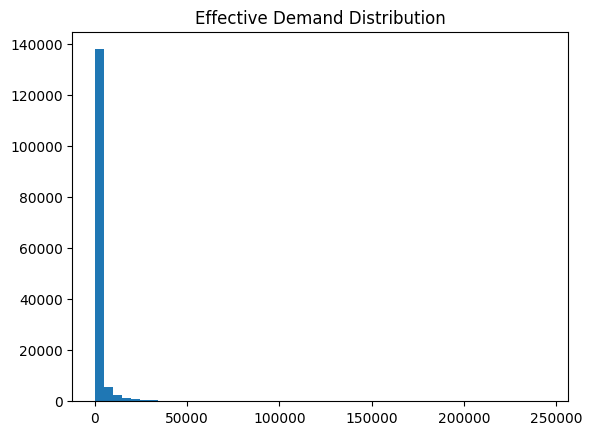

In [30]:
# Overall Distribution
plt.figure()
plt.hist(Data["Clean_Demand"], bins=50)
plt.title("Effective Demand Distribution")
plt.show()

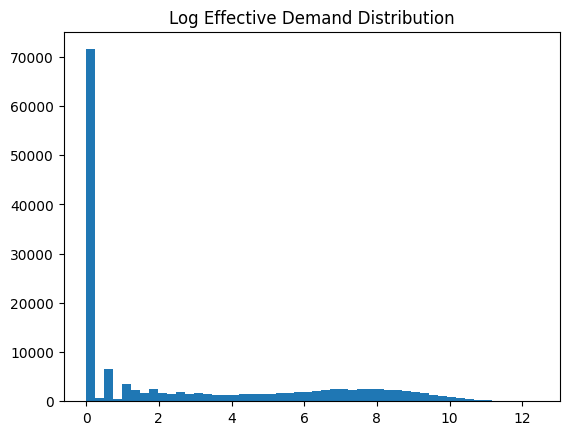

In [31]:
# Log Distribution
plt.figure()
plt.hist(np.log1p(Data["Clean_Demand"]), bins=50)
plt.title("Log Effective Demand Distribution")
plt.show()

In [32]:
print("Skewness:", Data["Clean_Demand"].skew())
print("Kurtosis:", Data["Clean_Demand"].kurt())

Skewness: 11.44305510836923
Kurtosis: 193.14321973898734


In [33]:
zero_ratio = (Data["Clean_Demand"]==0).mean()
print("Zero Demand Ratio:", zero_ratio)

Zero Demand Ratio: 0.47649726557289585


In [34]:
zero_ratio = (Data["Target"] == 0).mean()
print(zero_ratio)

0.4749032946511938


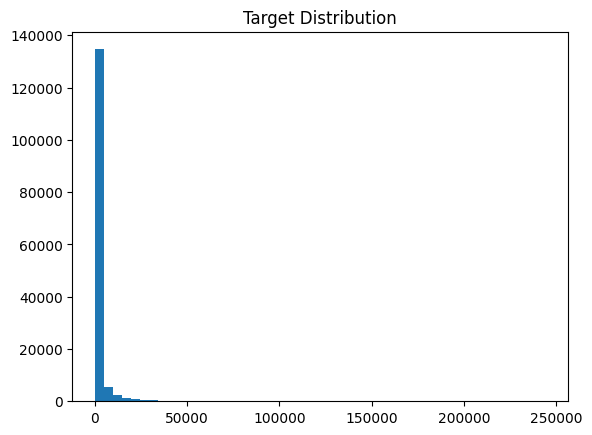

Target Skewness: 11.410952899952537


In [35]:
plt.figure()
plt.hist(Data["Target"], bins=50)
plt.title("Target Distribution")
plt.show()

print("Target Skewness:", Data["Target"].skew())

In [36]:
q99 = Data["Clean_Demand"].quantile(0.99)

print("99th percentile:", q99)
print("Max Demand:", Data["Clean_Demand"].max())

99th percentile: 31845.809999999707
Max Demand: 244345.8


In [37]:
sku_status = Data.groupby("ItemCode")["Clean_Demand"].agg(["mean", "std", "max", "min", "count"])
print(sku_status.describe())

                mean           std            max           min        count
count    3337.000000   3328.000000    3337.000000   3337.000000  3337.000000
mean     1499.272140    781.060450    3645.334705    198.518654    44.932574
std      6395.433464   3021.992533   13823.060648   1255.622752    19.788630
min         0.000000      0.000000       0.000000      0.000000     1.000000
25%         0.230769      0.629155       3.000000      0.000000    30.000000
50%         6.272727      7.193573      30.000000      0.000000    56.000000
75%       311.766667    268.158673    1174.000000      1.000000    60.000000
max    151261.665000  61885.238230  244345.800000  33010.000000    60.000000


### Save PP DATA

In [38]:
Data.to_csv("processed_data2.csv", index=False)

# Modelling

### Core Config

In [39]:
FEATURE_COLS = [
    "ItemCode", "ABC_Class",
    "Lag1","Lag2","Lag3","Lag6","Lag12",
    "Rolling3M_Mean","Rolling6M_Mean","Rolling3M_Std",
    "Momentum",
    "Month_Sin","Month_Cos",
    "Inventory_Pressure",
    "Bonus_Flag","Supply_Constraint_Flag",
    "Bonus_Shock","Supply_Shock",
    "Available_Primary_Inventory_Qty",
    "Distributor_Inventory_Qty",
    "Blocked_Stock_Qty",
    "ZeroRate_6M",
    "Net_Available_Stock", "Stock_Cover_Months"
]

'''Don't use Next_Month_Drop as Feature'''

"Don't use Next_Month_Drop as Feature"

### Helper Functions

##### Other

In [40]:
def sanitize(df):
    df = df.replace([np.inf, -np.inf], np.nan)
    return df.fillna(0)

def recency_weights(df, yearly_boost=0.25, base=1.0):
    y0 = df["Year"].min()
    return base + (df["Year"] - y0) * yearly_boost

def wmape(y_true, y_pred):
    denominator = np.sum(y_true)
    if denominator == 0:
        return 0
    return np.sum(np.abs(y_true - y_pred)) / denominator * 100

def forecast_bias(y_true, y_pred):
    denominator = np.sum(y_true)
    if denominator == 0:
        return 0
    return np.sum(y_pred - y_true) / denominator * 100

def evaluate_all_metrics(y_true, y_pred):
    return {
        "WMAPE": wmape(y_true, y_pred),
        "Bias": forecast_bias(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred))
    }

def recompute_target(df):
    df = df.copy()
    df[TARGET_COL] = df.groupby("ItemCode")["Clean_Demand"].shift(-1)
    return df

def rebuild_time_features(df):
    df = df.sort_values(["ItemCode", "Year", "Month_Number"]).copy()

    # ---- LAGS ----
    for lag in [1, 2, 3, 6, 12]:
        df[f"Lag{lag}"] = df.groupby("ItemCode")["Clean_Demand"].shift(lag)

    # ---- ROLLING STATS (shifted to avoid leakage) ----
    df["Rolling3M_Mean"] = (df.groupby("ItemCode")["Clean_Demand"].transform(lambda x: x.rolling(3, min_periods=1).mean().shift(1)))
    df["Rolling6M_Mean"] = (df.groupby("ItemCode")["Clean_Demand"].transform(lambda x: x.rolling(6, min_periods=1).mean().shift(1)))
    df["Rolling3M_Std"] = (df.groupby("ItemCode")["Clean_Demand"].transform(lambda x: x.rolling(3, min_periods=1).std().shift(1))).fillna(0)

    # ---- MOMENTUM ----
    df["Momentum"] = df["Lag1"] - df["Lag3"]

    # ---- ZERO BEHAVIOR ----
    df["Is_Zero"] = (df["Clean_Demand"] == 0).astype(int)
    df["ZeroRate_6M"] = (df.groupby("ItemCode")["Is_Zero"].transform(lambda x: x.rolling(6, min_periods=1).mean().shift(1))).fillna(0)

    # ---- INVENTORY PRESSURE ----
    lag1 = df["Lag1"].fillna(0)
    df["Inventory_Pressure"] = np.where(
        lag1 == 0,
        0,
        df["Available_Primary_Inventory_Qty"] / (lag1 + 1)
    )

    # ---- NET AVAILABLE STOCK ----
    required_stock_cols = {"Total_Primary_Inventory_Qty", "Blocked_Stock_Qty", "Inspection_Stock_Qty"}
    
    missing = required_stock_cols - set(df.columns)
    if missing:
        raise KeyError(f"Missing stock columns needed for Net_Available_Stock: {missing}")

    df["Net_Available_Stock"] = (df["Total_Primary_Inventory_Qty"] - df["Blocked_Stock_Qty"] - df["Inspection_Stock_Qty"]).clip(lower=0)

    # ---- STOCK COVER MONTHS ----
    cover = np.where(
        df["Rolling3M_Mean"].fillna(0) == 0,
        0,
        df["Net_Available_Stock"] / (df["Rolling3M_Mean"] + 1)
    )
    
    df["Stock_Cover_Months"] = pd.Series(cover, index=df.index)
    
    return df

def compute_clip_caps(train_df, cols, q=0.99):
    """Compute clipping caps using TRAIN only."""
    caps = {}
    for c in cols:
        if c in train_df.columns:
            caps[c] = float(train_df[c].replace([np.inf, -np.inf], np.nan).dropna().quantile(q))
    return caps

def apply_clip_caps(df, caps):
    """Apply previously computed caps to any df."""
    df = df.copy()
    for c, cap in caps.items():
        if c in df.columns:
            df[c] = df[c].clip(upper=cap)
    return df

def assert_features_exist(df, feature_cols, where=""):
    missing = [c for c in feature_cols if c not in df.columns]
    if missing:
        raise KeyError(f"[{where}] Missing required features: {missing}")


##### Fold Adjustments

In [41]:
# ItemCode Encoding
def encode_itemcode(train_df, valid_df):
    categories = train_df["ItemCode"].astype("category").cat.categories
    train_df["ItemCode"] = pd.Categorical(train_df["ItemCode"], categories=categories).codes
    valid_df["ItemCode"] = pd.Categorical(valid_df["ItemCode"], categories=categories).codes
    return train_df, valid_df, categories

# SKU Cap Function
def apply_sku_cap(train_df, valid_df, quantile=0.995):
    train_df = train_df.copy()
    valid_df = valid_df.copy()

    sku_cap = (train_df.groupby("ItemCode")["Clean_Demand"].quantile(quantile))

    train_df["Clean_Demand"] = np.minimum(train_df["Clean_Demand"], train_df["ItemCode"].map(sku_cap))
    valid_df["Clean_Demand"] = np.minimum(valid_df["Clean_Demand"], valid_df["ItemCode"].map(sku_cap))

    return train_df, valid_df

# ABC Classification Function
def apply_abc_classification(train_df, valid_df):

    train_df = train_df.copy()
    valid_df = valid_df.copy()

    sku_total = (
        train_df.groupby("ItemCode")["Clean_Demand"]
        .sum()
        .sort_values(ascending=False)
    )

    cum_pct = sku_total.cumsum() / sku_total.sum()

    abc_series = pd.cut(
        cum_pct,
        bins=[0, 0.7, 0.9, 1.0],
        labels=[0, 1, 2]
    )

    abc_map = abc_series.to_dict()

    train_df["ABC_Class"] = train_df["ItemCode"].map(abc_map).fillna(2)
    valid_df["ABC_Class"] = valid_df["ItemCode"].map(abc_map).fillna(2)

    return train_df, valid_df, abc_map

# Combined Wrapper
def apply_fold_adjustments(train_df, valid_df):
    train_df, valid_df = apply_sku_cap(train_df, valid_df)
    train_df, valid_df, abc_map = apply_abc_classification(train_df, valid_df)

    return train_df, valid_df, abc_map

In [42]:
# Drop NaNs
Required_cols = ["Target", "Lag1", "Lag2", "Lag3", "Lag6", "Lag12", 
                "Rolling3M_Mean", "Rolling6M_Mean", 
                "Rolling3M_Std"]

Data = Data.dropna(subset=Required_cols).copy()
Data = Data[Data["Target"] >= 0].copy()

##### Final 2025 Function

In [43]:
def train_eval_fixed_split_lgbm(Data, feature_cols, target_col, params, yearly_boost=0.25):
    train_df = Data[Data["Year"] < 2025].copy()
    test_df  = Data[Data["Year"] == 2025].copy()
    if train_df.empty or test_df.empty:
        raise ValueError("Need both train (<2025) and test (2025) data.")

    # Fold adjustments (train-only stats)
    train_df, test_df, abc_map = apply_fold_adjustments(train_df, test_df)

    # Clip caps (train only) for sensitive columns
    caps = compute_clip_caps(train_df, cols=["Inventory_Pressure", "Stock_Cover_Months"], q=0.99)
    train_df = apply_clip_caps(train_df, caps)
    test_df  = apply_clip_caps(test_df, caps)

    # Encode ItemCode train-only
    train_df, test_df, itemcode_categories = encode_itemcode(train_df, test_df)

    # Feature checks
    assert_features_exist(train_df, feature_cols, where="TRAIN")
    assert_features_exist(test_df,  feature_cols, where="TEST")

    # Weights
    w_train = recency_weights(train_df, yearly_boost=yearly_boost)

    # Build datasets
    X_train = sanitize(train_df[feature_cols])
    y_train = train_df[target_col].values
    X_test  = sanitize(test_df[feature_cols])
    y_test  = test_df[target_col].values

    # Train LightGBM
    model = lgb.LGBMRegressor(**params)
    model.fit(
        X_train, y_train,
        sample_weight=w_train,
        eval_set=[(X_test, y_test)],
        eval_metric="rmse",
        callbacks=[lgb.early_stopping(stopping_rounds=200, verbose=False)]
    )

    preds = model.predict(X_test)
    test_df["Pred"] = preds

    metrics = evaluate_all_metrics(y_test, preds)
    return model, test_df, metrics, itemcode_categories, abc_map, caps


### Tune

In [48]:

TUNE_YEARS = [2023, 2024]

def objective(trial):
    params = {
        # Objective suited for demand (zero-heavy, continuous-ish):
        "objective": "tweedie",
        "tweedie_variance_power": trial.suggest_float("tweedie_variance_power", 1.2, 1.55),

        # Tree / boosting params
        "n_estimators": trial.suggest_int("n_estimators", 1200, 6000),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.06),
        "num_leaves": trial.suggest_int("num_leaves", 32, 256),
        "max_depth": trial.suggest_int("max_depth", 4, 10),
        "min_child_samples": trial.suggest_int("min_child_samples", 20, 120),

        # Sampling
        "subsample": trial.suggest_float("subsample", 0.70, 0.95),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.70, 0.95),

        # Regularization
        "reg_lambda": trial.suggest_float("reg_lambda", 0.0, 15.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 0.0, 5.0),

        # Misc
        "random_state": 42,
        "n_jobs": -1
    }

    scores = []

    for year in TUNE_YEARS:
        train = Data[Data["Year"] < year].copy()
        valid = Data[Data["Year"] == year].copy()

        if train.empty or valid.empty:
            continue

        # Fold adjustments
        train, valid, _ = apply_fold_adjustments(train, valid)

        # Clip caps (train-only)
        caps = compute_clip_caps(train, cols=["Inventory_Pressure", "Stock_Cover_Months"], q=0.99)
        train = apply_clip_caps(train, caps)
        valid = apply_clip_caps(valid, caps)

        # Encode ItemCode with train categories only
        train, valid, _ = encode_itemcode(train, valid)

        assert_features_exist(train, FEATURE_COLS, where=f"TUNE-TRAIN-{year}")
        assert_features_exist(valid, FEATURE_COLS, where=f"TUNE-VALID-{year}")

        w_train = recency_weights(train, yearly_boost=0.25)

        Xtr = sanitize(train[FEATURE_COLS])
        ytr = train[TARGET_COL].values
        Xva = sanitize(valid[FEATURE_COLS])
        yva = valid[TARGET_COL].values

        model = lgb.LGBMRegressor(**params)
        model.fit(
            Xtr, ytr,
            sample_weight=w_train,
            eval_set=[(Xva, yva)],
            eval_metric="rmse",
            callbacks=[lgb.early_stopping(200, verbose=False)]
        )

        pred = model.predict(Xva)
        scores.append(wmape(yva, pred))

    if len(scores) == 0:
        return 1e9

    return float(np.mean(scores))


In [49]:

study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=40)

best_params = study.best_params
# Add fixed params required by LightGBM estimator
best_params.update({"objective": "tweedie", "random_state": 42, "n_jobs": -1})

print("\n✅ Best Params:", best_params)

[I 2026-03-02 22:02:44,439] A new study created in memory with name: no-name-6a8a3bfb-9b2e-467a-b147-6820d6872ee2


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001076 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4119
[LightGBM] [Info] Number of data points in the train set: 17740, number of used features: 24
[LightGBM] [Info] Start training from score 7.768575
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain:

[I 2026-03-02 22:02:50,716] Trial 0 finished with value: 29.28834908137051 and parameters: {'tweedie_variance_power': 1.2984212414700327, 'n_estimators': 3701, 'learning_rate': 0.054770804646714674, 'num_leaves': 69, 'max_depth': 9, 'min_child_samples': 114, 'subsample': 0.7077979744630726, 'colsample_bytree': 0.7648128534078709, 'reg_lambda': 9.481837404128006, 'reg_alpha': 3.308533449949584}. Best is trial 0 with value: 29.28834908137051.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000799 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4119
[LightGBM] [Info] Number of data points in the train set: 17740, number of used features: 24
[LightGBM] [Info] Start training from score 7.768575
[LightGBM] [Warning] No further splits with positive gain, best gain:

[I 2026-03-02 22:02:55,755] Trial 1 finished with value: 29.62563862469964 and parameters: {'tweedie_variance_power': 1.2820815828394152, 'n_estimators': 1735, 'learning_rate': 0.014853405216036977, 'num_leaves': 75, 'max_depth': 4, 'min_child_samples': 101, 'subsample': 0.8351054301659361, 'colsample_bytree': 0.7934366439607702, 'reg_lambda': 4.234748882572035, 'reg_alpha': 0.7780762315379575}. Best is trial 0 with value: 29.28834908137051.


...

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000797 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4119
[LightGBM] [Info] Number of data points in the train set: 17740, number of used features: 24
[LightGBM] [Info] Start training from score 7.768575
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain:

[I 2026-03-02 22:09:42,327] Trial 38 finished with value: 29.045749812602445 and parameters: {'tweedie_variance_power': 1.288365380583138, 'n_estimators': 3501, 'learning_rate': 0.02704506028358314, 'num_leaves': 255, 'max_depth': 7, 'min_child_samples': 44, 'subsample': 0.9008222845481642, 'colsample_bytree': 0.8039966851881502, 'reg_lambda': 12.11507580515561, 'reg_alpha': 1.4583807611474862}. Best is trial 31 with value: 28.84479633084403.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2026-03-02 22:09:51,258] Trial 39 finished with value: 28.972982855621407 and parameters: {'tweedie_variance_power': 1.2185661252838074, 'n_estimators': 4237, 'learning_rate': 0.015188531100726455, 'num_leaves': 184, 'max_depth': 6, 'min_child_samples': 26, 'subsample': 0.8531349947830797, 'colsample_bytree': 0.8368767729229223, 'reg_lambda': 13.622503546813993, 'reg_alpha': 0.7533099513602526}. Best is trial 31 with value: 28.84479633084403.



✅ Best Params: {'tweedie_variance_power': 1.263926193745186, 'n_estimators': 5428, 'learning_rate': 0.029214461696887628, 'num_leaves': 125, 'max_depth': 9, 'min_child_samples': 24, 'subsample': 0.8039407967603056, 'colsample_bytree': 0.7375608590133745, 'reg_lambda': 13.832969446151035, 'reg_alpha': 0.012437937393507487, 'objective': 'tweedie', 'random_state': 42, 'n_jobs': -1}


### Final Production Train

In [50]:

final_model, test_2025, metrics_2025, itemcode_categories, abc_map, clip_caps = train_eval_fixed_split_lgbm(
    Data=Data,
    feature_cols=FEATURE_COLS,
    target_col=TARGET_COL,
    params=best_params
)

print("\n========== FINAL LGBM MODEL → 2025 ==========")
print("✅ Metrics:", metrics_2025)

print("\n2025 WMAPE by ABC:")
print(
    test_2025.groupby("ABC_Class", group_keys=False)
             .apply(lambda x: wmape(x[TARGET_COL].values, x["Pred"].values))
)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001396 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4120
[LightGBM] [Info] Number of data points in the train set: 74134, number of used features: 24
[LightGBM] [Info] Start training from score 7.563057
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain:

/var/folders/np/7_nptc2d6pjch6_bcrs_2wjc0000gn/T/ipykernel_14868/3284527950.py:13: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  test_2025.groupby("ABC_Class", group_keys=False)


### Save Trained Model

In [53]:
artifacts = {
    "model": final_model,
    "feature_cols": FEATURE_COLS,
    "best_params": best_params,
    "itemcode_categories": itemcode_categories,
    "abc_map": abc_map,
    "clip_caps": clip_caps
}

joblib.dump(artifacts, "lgbm_model_artifacts.pkl")
print("\n✅ Saved: lgbm_model_artifacts.pkl")


✅ Saved: lgbm_model_artifacts.pkl


# Inference

In [54]:
def forward_next_month_forecast_lgbm(sku_code, artifacts, raw_data):
    model = artifacts["model"]
    feature_cols = artifacts["feature_cols"]
    itemcode_categories = artifacts["itemcode_categories"]
    abc_map = artifacts["abc_map"]
    caps = artifacts.get("clip_caps", None)

    df = raw_data.copy().sort_values(["ItemCode","Year","Month_Number"])

    # Ensure ABC exists
    df["ABC_Class"] = df["ItemCode"].map(abc_map).fillna(2)

    # Encode ItemCode using train categories
    df["ItemCode_Original"] = df["ItemCode"]
    df["ItemCode"] = pd.Categorical(df["ItemCode"], categories=itemcode_categories).codes
    encoded_sku = pd.Categorical([sku_code], categories=itemcode_categories).codes[0]
    if encoded_sku == -1:
        print("❌ SKU not found in trained categories.")
        return None

    sku_df = df[df["ItemCode"] == encoded_sku].sort_values(["Year","Month_Number"])
    if sku_df.empty:
        print("❌ SKU has no history.")
        return None

    last_row = sku_df.iloc[-1:].copy()
    next_month = int(last_row["Month_Number"].values[0] + 1)
    next_year = int(last_row["Year"].values[0])
    if next_month > 12:
        next_month = 1
        next_year += 1

    # Create next row by copying last known row
    new_row = last_row.copy()
    new_row["Year"] = next_year
    new_row["Month_Number"] = next_month

    # Optional: set unknown future flags to neutral (recommended)
    for c in ["Bonus_Flag","Supply_Constraint_Flag","Bonus_Shock","Supply_Shock"]:
        if c in new_row.columns:
            new_row[c] = 0

    # Append and rebuild ONLY the time-dependent engineered features
    df_ext = pd.concat([df, new_row], ignore_index=True).sort_values(["ItemCode","Year","Month_Number"])

    # Rebuild time features for df_ext (minimal subset)
    # Lags
    for lag in [1, 2, 3, 6, 12]:
        df_ext[f"Lag{lag}"] = df_ext.groupby("ItemCode")["Clean_Demand"].shift(lag)

    # Rolling
    df_ext["Rolling3M_Mean"] = df_ext.groupby("ItemCode")["Clean_Demand"].transform(lambda x: x.rolling(3, min_periods=1).mean().shift(1))
    df_ext["Rolling6M_Mean"] = df_ext.groupby("ItemCode")["Clean_Demand"].transform(lambda x: x.rolling(6, min_periods=1).mean().shift(1))
    df_ext["Rolling3M_Std"]  = df_ext.groupby("ItemCode")["Clean_Demand"].transform(lambda x: x.rolling(3, min_periods=1).std().shift(1)).fillna(0)

    # Momentum
    df_ext["Momentum"] = df_ext["Lag1"] - df_ext["Lag3"]

    # Seasonality
    df_ext["Month_Sin"] = np.sin(2 * np.pi * df_ext["Month_Number"] / 12)
    df_ext["Month_Cos"] = np.cos(2 * np.pi * df_ext["Month_Number"] / 12)

    # Zero rate
    df_ext["Is_Zero"] = (df_ext["Clean_Demand"] == 0).astype(int)
    df_ext["ZeroRate_6M"] = df_ext.groupby("ItemCode")["Is_Zero"].transform(lambda x: x.rolling(6, min_periods=1).mean().shift(1)).fillna(0)

    # Inventory pressure
    if "Available_Primary_Inventory_Qty" in df_ext.columns:
        lag1 = df_ext["Lag1"].fillna(0)
        df_ext["Inventory_Pressure"] = np.where(lag1 == 0, 0, df_ext["Available_Primary_Inventory_Qty"] / (lag1 + 1))

    # Net available stock + cover
    if {"Total_Primary_Inventory_Qty","Blocked_Stock_Qty","Inspection_Stock_Qty"}.issubset(df_ext.columns):
        df_ext["Net_Available_Stock"] = (
            df_ext["Total_Primary_Inventory_Qty"] - df_ext["Blocked_Stock_Qty"] - df_ext["Inspection_Stock_Qty"]
        ).clip(lower=0)

        df_ext["Stock_Cover_Months"] = np.where(
            df_ext["Rolling3M_Mean"].fillna(0) == 0,
            0,
            df_ext["Net_Available_Stock"] / (df_ext["Rolling3M_Mean"] + 1)
        )

    # Apply clip caps
    if caps is not None:
        df_ext = apply_clip_caps(df_ext, caps)

    # Select next row
    next_row = df_ext[
        (df_ext["ItemCode"] == encoded_sku) &
        (df_ext["Year"] == next_year) &
        (df_ext["Month_Number"] == next_month)
    ]

    if next_row.empty:
        print("❌ Next month row not created correctly.")
        return None

    assert_features_exist(next_row, feature_cols, where="INFERENCE-NEXT_ROW")
    X_next = sanitize(next_row[feature_cols])
    pred = float(model.predict(X_next)[0])

    # Optional: enforce hard-zero for near-always-zero SKUs
    zr = float(next_row["ZeroRate_6M"].values[0]) if "ZeroRate_6M" in next_row.columns else 0
    if zr > 0.95 and pred < 50:
        pred = 0.0

    return {"SKU": sku_code, "Year": next_year, "Month": next_month, "Forecast": pred}


In [55]:
artifacts_loaded = joblib.load("lgbm_model_artifacts.pkl")
result = forward_next_month_forecast_lgbm(600172, artifacts_loaded, Data)
print(result)

{'SKU': 600172, 'Year': 2026, 'Month': 2, 'Forecast': 0.55549718354}
